# Dyslexia Detection from Handwriting — Modelling (2025 rebuild)

This notebook replaces the two 2024 notebooks
(`legacy/Detection_Of_Dyslexia_From_Handwriting.ipynb` and
`legacy/model_training/dyslexia_detection.ipynb`).

It trains and evaluates the three models the app blends:

| Part | Model | Data |
|---|---|---|
| **A** | Tabular classifier over 4 linguistic features | `data/linguistic_features.csv` |
| **B** | Whole-sample image classifier (YOLO11-cls) | `data/samples/{train,test}` |
| **C** | Per-letter classifier (ConvNeXt-Tiny) | Gambo *Dyslexia Handwriting Dataset* |
| **D** | Blended ensemble evaluation | held-out samples |

All reusable logic lives in `src/dyslexia/`; the notebook is orchestration +
analysis only.

> ⚠️ Research demo, not a diagnostic tool.

In [1]:
# Setup — run from the repo root
%load_ext autoreload
%autoreload 2

import sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / "src" / "dyslexia").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)

from dyslexia.config import load_config
CFG = load_config(ROOT / "config.yaml")
CFG["paths"]

{'linguistic_features_csv': WindowsPath('C:/Users/rumma/Desktop/Dyslexia-Detection-from-Handwriting/data/linguistic_features.csv'),
 'samples_dir': WindowsPath('C:/Users/rumma/Desktop/Dyslexia-Detection-from-Handwriting/data/samples'),
 'gambo_dir': WindowsPath('C:/Users/rumma/Desktop/Dyslexia-Detection-from-Handwriting/data/gambo'),
 'gambo_zip': WindowsPath('C:/Users/rumma/Desktop/Dyslexia-Detection-from-Handwriting/Gambo.zip'),
 'models_dir': WindowsPath('C:/Users/rumma/Desktop/Dyslexia-Detection-from-Handwriting/models')}

---
## Part A · Tabular linguistic model

In [2]:
from dyslexia.datasets import load_linguistic_dataset
from dyslexia.features import FEATURE_NAMES

df = load_linguistic_dataset()
print(df.shape)
df.groupby("presence_of_dyslexia")[list(FEATURE_NAMES)].agg(["mean", "std"]).T

(100, 5)


presence_of_dyslexia                 0       1
spelling_accuracy         mean  98.449  91.416
                          std    0.778   6.713
grammatical_accuracy      mean  99.551  98.328
                          std    0.168   6.992
percentage_of_corrections mean   6.798  13.031
                          std    3.298   7.753
phonetic_accuracy         mean  98.868  93.998
                          std    0.595   5.267

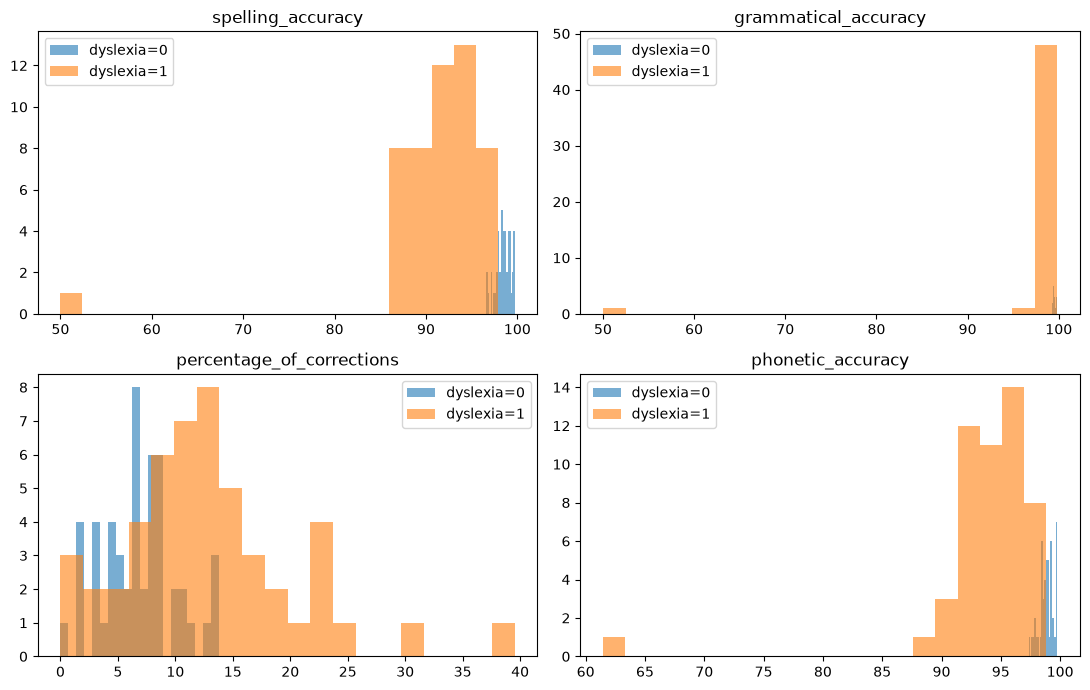

In [3]:
# EDA — feature distributions by group
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat in zip(axes.ravel(), FEATURE_NAMES):
    for label, sub in df.groupby("presence_of_dyslexia"):
        ax.hist(sub[feat], bins=20, alpha=.6, label=f"dyslexia={label}")
    ax.set_title(feat); ax.legend()
fig.tight_layout()

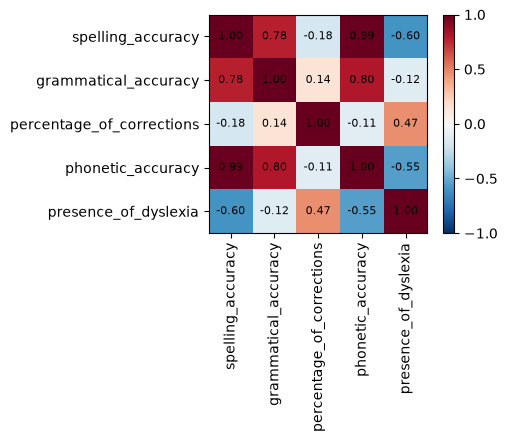

In [4]:
# Correlation structure
import numpy as np
corr = df[list(FEATURE_NAMES) + ["presence_of_dyslexia"]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for (i, j), v in np.ndenumerate(corr.values):
    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); fig.tight_layout()

In [5]:
from sklearn.model_selection import train_test_split
from dyslexia.tabular import select_best, build_candidates

tcfg = CFG["tabular"]
X, y = df[list(FEATURE_NAMES)], df[tcfg["target"]]
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=tcfg["test_size"], stratify=y, random_state=tcfg["random_state"]
)

best_name, cv_scores = select_best(X_tr, y_tr, cv_folds=tcfg["cv_folds"],
                                   random_state=tcfg["random_state"])
pd.Series(cv_scores, name="cv_roc_auc").sort_values(ascending=False)

c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwrit

random_forest          0.972
svm_rbf                0.972
logistic_regression    0.969
gradient_boosting      0.969
xgboost                0.969
Name: cv_roc_auc, dtype: float64

In [6]:
# Compare candidates on several metrics via cross-validation
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(n_splits=tcfg["cv_folds"], shuffle=True, random_state=tcfg["random_state"])
rows = []
for name, model in build_candidates(tcfg["random_state"]).items():
    res = cross_validate(model, X_tr, y_tr, cv=cv,
                         scoring=["roc_auc", "accuracy", "f1", "average_precision"])
    rows.append({"model": name, **{k.replace("test_", ""): np.mean(v)
                                   for k, v in res.items() if k.startswith("test_")}})
pd.DataFrame(rows).set_index("model").sort_values("roc_auc", ascending=False)

c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwrit

,roc_auc,accuracy,f1,average_precision
model,,,,
random_forest,0.972,0.912,0.904,0.979
svm_rbf,0.972,0.925,0.912,0.978
logistic_regression,0.969,0.925,0.915,0.979
gradient_boosting,0.969,0.887,0.890,0.969
xgboost,0.969,0.925,0.921,0.976


In [7]:
from dyslexia.tabular import TabularModel

model = TabularModel.train(X_tr, y_tr, algorithm=best_name, calibrate=True,
                           cv_folds=tcfg["cv_folds"], random_state=tcfg["random_state"])
model.algorithm, model.trained_at

('random_forest', '2026-08-31T19:21:57')

ROC-AUC: 1.000
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        10
           1      1.000     1.000     1.000        10

    accuracy                          1.000        20
   macro avg      1.000     1.000     1.000        20
weighted avg      1.000     1.000     1.000        20



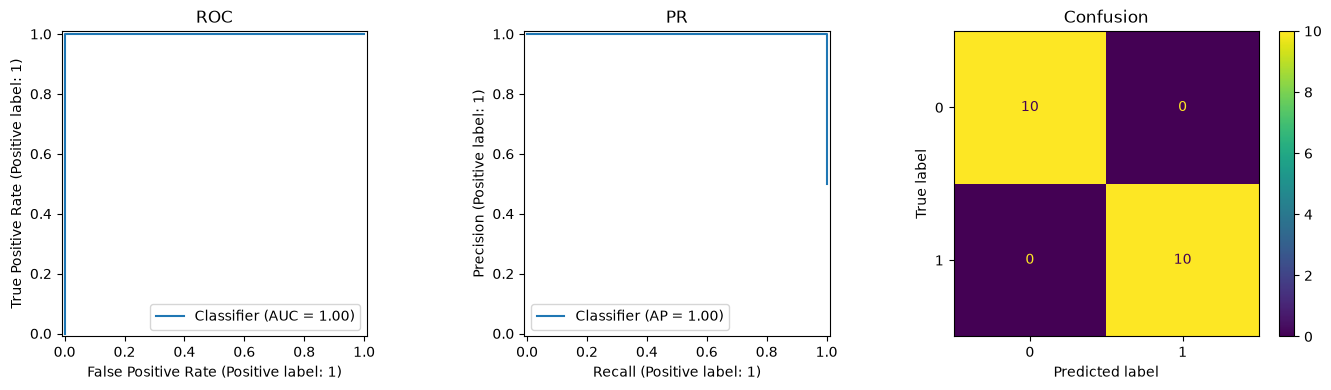

In [8]:
# Hold-out evaluation
from sklearn.metrics import (RocCurveDisplay, PrecisionRecallDisplay,
                             ConfusionMatrixDisplay, classification_report, roc_auc_score)

proba = model.predict_proba(X_te)
pred = (proba >= CFG["ensemble"]["decision_threshold"]).astype(int)
print(f"ROC-AUC: {roc_auc_score(y_te, proba):.3f}")
print(classification_report(y_te, pred, digits=3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
RocCurveDisplay.from_predictions(y_te, proba, ax=axes[0]); axes[0].set_title("ROC")
PrecisionRecallDisplay.from_predictions(y_te, proba, ax=axes[1]); axes[1].set_title("PR")
ConfusionMatrixDisplay.from_predictions(y_te, pred, ax=axes[2]); axes[2].set_title("Confusion")
fig.tight_layout()

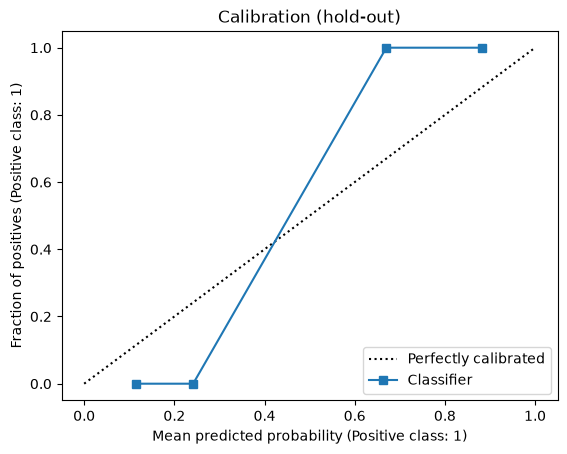

In [9]:
# Calibration curve
from sklearn.calibration import CalibrationDisplay
CalibrationDisplay.from_predictions(y_te, proba, n_bins=5)
plt.title("Calibration (hold-out)"); plt.show()

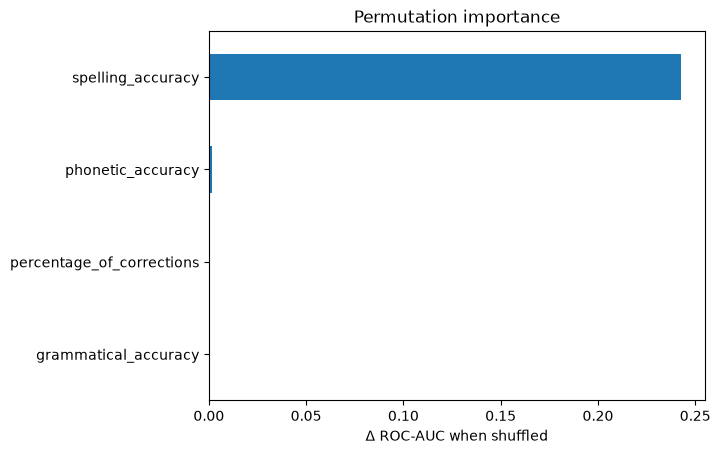

In [10]:
# Permutation importance (model-agnostic)
from sklearn.inspection import permutation_importance
imp = permutation_importance(model.pipeline, X_te, y_te, n_repeats=50,
                             random_state=0, scoring="roc_auc")
pd.Series(imp.importances_mean, index=FEATURE_NAMES).sort_values().plot.barh()
plt.xlabel("Δ ROC-AUC when shuffled"); plt.title("Permutation importance"); plt.show()

In [11]:
# SHAP explanations (optional dependency)
try:
    import shap
    bg = X_tr.sample(min(100, len(X_tr)), random_state=0)
    explainer = shap.Explainer(lambda d: model.pipeline.predict_proba(
        pd.DataFrame(d, columns=list(FEATURE_NAMES)))[:, 1], bg)
    sv = explainer(X_te)
    shap.plots.beeswarm(sv, max_display=4)
except Exception as e:
    print("SHAP skipped:", e)

SHAP skipped: No module named 'shap'


In [12]:
# Persist the fitted model for the app.
# NOTE: a joblib pickle is tied to the scikit-learn version that created it.
# Train and run the app in the same environment (requirements.txt), or rebuild
# with `python scripts/train_tabular.py`.
path = model.save(CFG["tabular"]["model_path"])
print("saved ->", path)
TabularModel.load(path).predict_proba([98, 99, 6, 98])

saved -> C:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\models\tabular\model.joblib


array([0.39880401])

> **Note on feature drift.** `linguistic_features.csv` was produced in 2024 with
> the Azure Read API + Bing Spell-Check + `abydos`. The app now uses `easyocr` +
> `pyspellchecker` + `jellyfish`. To retrain on features from the *current*
> pipeline, run the cell below (needs `easyocr`, slow on CPU) and re-run Part A.

In [14]:
# OPTIONAL — regenerate the feature table from raw images with the offline pipeline
REGENERATE = False
if REGENERATE:
    from dyslexia.features import FeatureExtractor
    from dyslexia.datasets import iter_sample_images
    fx = FeatureExtractor(CFG["ocr"]["engine"])
    records = []
    for img_path, label in iter_sample_images("all"):
        f = fx.from_image(img_path)
        records.append({**f.as_dict(), "presence_of_dyslexia": label,
                        "source": img_path.name})
    regen = pd.DataFrame(records)
    regen.to_csv(ROOT / "data/features/linguistic_features_offline.csv", index=False)
    regen.describe()

c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\.venv\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
c:\Users\rumma\Desktop\Dyslexia-Detection-from-Handwriting\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

---
## Part B · Whole-sample image classifier (YOLO11-cls)

The 2024 project trained `yolov8n-cls`. We move to **YOLO11n-cls** (same Ultralytics API). Needs a GPU for comfort — run this part on Colab/Kaggle. The pretrained 2024 weights are kept at `models/image/yolo_samples_best_v3.pt` as a fallback.

In [ ]:
# Ultralytics expects <root>/train/<class>/*.jpg and <root>/val/<class>/*.jpg
import shutil, pathlib
samples = pathlib.Path(CFG["paths"]["samples_dir"])
yolo_root = ROOT / "data/yolo_cls"
if not yolo_root.exists():
    for split_src, split_dst in [("train", "train"), ("test", "val")]:
        for cls in ["dyslexic", "non_dyslexic"]:
            src = samples / split_src / cls
            dst = yolo_root / split_dst / cls
            dst.mkdir(parents=True, exist_ok=True)
            for p in src.glob("*.jpg"):
                shutil.copy(p, dst / p.name)
print(sorted(yolo_root.rglob("*"))[:4], "...")

In [ ]:
try:
    from ultralytics import YOLO
    model_img = YOLO("yolo11n-cls.pt")
    results = model_img.train(data=str(yolo_root), epochs=40, imgsz=CFG["image"]["img_size"],
                              batch=16, seed=0, project=str(ROOT / "runs"), name="samples")
    metrics = model_img.val()
    print("top-1:", metrics.top1)
    # promote to the location the app loads
    best = pathlib.Path(results.save_dir) / "weights" / "best.pt"
    shutil.copy(best, ROOT / CFG["image"]["yolo_weights"])
except Exception as e:
    print("YOLO training skipped (no ultralytics / GPU):", e)

In [ ]:
# Quick sanity check with whichever weights are present
from dyslexia.image_models import YoloSampleClassifier
clf = YoloSampleClassifier(CFG["image"]["yolo_weights"])
if clf.available:
    from dyslexia.datasets import iter_sample_images
    ys, ps = [], []
    for p, label in iter_sample_images("test"):
        ys.append(label); ps.append(clf.predict_proba(p))
    from sklearn.metrics import roc_auc_score
    print("test ROC-AUC:", roc_auc_score(ys, ps))
else:
    print("classifier unavailable:", clf._error)

---
## Part C · Per-letter classifier on the Gambo dataset

Kaggle *Dyslexia Handwriting Dataset* (Gambo): letter images labelled `Normal` / `Reversal` / `Corrected`. We fine-tune **ConvNeXt-Tiny** from `timm`. Place `Gambo.zip` at the repo root first.

In [ ]:
from dyslexia.datasets import prepare_gambo
try:
    gdir = prepare_gambo()
    train_dir = next(p for p in [gdir / "Gambo" / "Train", gdir / "Train"] if p.exists())
    test_dir = next(p for p in [gdir / "Gambo" / "Test", gdir / "Test"] if p.exists())
    print(train_dir, test_dir)
    for cls_dir in sorted(train_dir.iterdir()):
        print(f"  {cls_dir.name:<12} {sum(1 for _ in cls_dir.glob('*.png'))}")
except Exception as e:
    print("Gambo not available:", e)

In [ ]:
GAMBO_EPOCHS = 3   # bump on GPU
try:
    import torch, timm
    from torch.utils.data import DataLoader
    from torchvision import datasets, transforms

    classes = CFG["image"]["gambo_classes"]
    size = CFG["image"]["img_size"]
    norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    tf_train = transforms.Compose([transforms.Grayscale(3), transforms.Resize((size, size)),
                                   transforms.RandomRotation(8), transforms.ToTensor(), norm])
    tf_eval = transforms.Compose([transforms.Grayscale(3), transforms.Resize((size, size)),
                                  transforms.ToTensor(), norm])

    ds_tr = datasets.ImageFolder(train_dir, tf_train)
    ds_te = datasets.ImageFolder(test_dir, tf_eval)
    assert ds_tr.classes == classes, (ds_tr.classes, classes)
    dl_tr = DataLoader(ds_tr, batch_size=128, shuffle=True, num_workers=2)
    dl_te = DataLoader(ds_te, batch_size=256, num_workers=2)

    dev = "cuda" if torch.cuda.is_available() else "cpu"
    net = timm.create_model("convnext_tiny", pretrained=True, num_classes=len(classes)).to(dev)
    opt = torch.optim.AdamW(net.parameters(), lr=3e-4)
    lossf = torch.nn.CrossEntropyLoss()

    for epoch in range(GAMBO_EPOCHS):
        net.train()
        for xb, yb in dl_tr:
            opt.zero_grad()
            loss = lossf(net(xb.to(dev)), yb.to(dev))
            loss.backward(); opt.step()
        print(f"epoch {epoch}: last batch loss {loss.item():.3f}")
except Exception as e:
    print("Gambo training skipped:", e)

In [ ]:
try:
    net.eval(); correct = total = 0
    ys, preds = [], []
    with torch.no_grad():
        for xb, yb in dl_te:
            out = net(xb.to(dev)).argmax(1).cpu()
            ys += yb.tolist(); preds += out.tolist()
            correct += (out == yb).sum().item(); total += len(yb)
    print(f"Gambo test accuracy: {correct/total:.3f}")
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    ConfusionMatrixDisplay(confusion_matrix(ys, preds), display_labels=classes).plot()

    ROOT.joinpath("models/image").mkdir(parents=True, exist_ok=True)
    torch.save({"model": net.state_dict(), "classes": classes},
               ROOT / CFG["image"]["gambo_weights"])
    print("saved ->", CFG["image"]["gambo_weights"])
except Exception as e:
    print("skipped:", e)

---
## Part D · Blended ensemble

`DyslexiaScreener` loads whichever models exist and renormalises the blend weights. Here we run it over the held-out handwriting samples.

In [ ]:
from dyslexia.screener import DyslexiaScreener
screener = DyslexiaScreener(CFG)
screener.component_status

In [ ]:
from dyslexia.datasets import iter_sample_images
from sklearn.metrics import roc_auc_score, classification_report

rows = []
for p, label in iter_sample_images("test"):
    res = screener.screen(p)
    rows.append({"file": p.name, "label": label, "risk": res.risk_score, **res.signals})
ens = pd.DataFrame(rows)
signal_cols = [c for c in ("tabular", "yolo", "gambo") if c in ens.columns]
if signal_cols:
    print("Ensemble ROC-AUC:", roc_auc_score(ens.label, ens.risk))
    print(classification_report(ens.label, (ens.risk >= 0.5).astype(int),
                                digits=3, zero_division=0))
else:
    print("No signals produced — install the app requirements and rerun Parts A-C.")
ens.head(10)

---
## Summary

- **Part A** — best tabular model selected by CV, calibrated, saved to
  `models/tabular/model.joblib`. The four linguistic features separate the two
  groups very cleanly on this small dataset.
- **Part B** — YOLO11n-cls whole-sample classifier; retrain on GPU, weights land
  at `models/image/yolo_samples_best_v3.pt`.
- **Part C** — ConvNeXt-Tiny per-letter model on Gambo; weights at
  `models/image/gambo_convnext.pt`.
- **Part D** — `DyslexiaScreener` blends them (weights in `config.yaml`).

Next: `streamlit run streamlit_app.py`.